In [1]:
# use holodeck environment

In [1]:
# making sure the notebook is run from the right directory, as lots of paths are relative to the root directory
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]

if not (PROJECT_ROOT / 'holodeck_output_lib_gp_mcmc').exists():
    raise RuntimeError("Please run Jupyter from the notebooks_and_files_for_final_results directory")


In [3]:
import holodeck as holo
import holodeck
from holodeck.constants import YR, NWTG, SPLC, GYR, PC, MSOL
from holodeck.galaxy_profiles import NFW
from holodeck import utils
from holodeck.librarian import DEF_NUM_FBINS, DEF_NUM_LOUDEST, DEF_PTA_DUR
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from scipy.integrate import solve_ivp, quad
import numpy as np
import kalepy as kale
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import os
import la_forge.core as co
from ceffyl.chain_utils import chain_utils
import la_forge.diagnostics as dg
from chainconsumer.chainconsumer import ChainConsumer
from emcee.autocorr import integrated_time

import numpy as np
import matplotlib.pyplot as plt

PINT not installed. PINT or libstempo are required to use par and tim files.


## MCMC using GPs (figure 6)

updated chain length: (274100, 6)


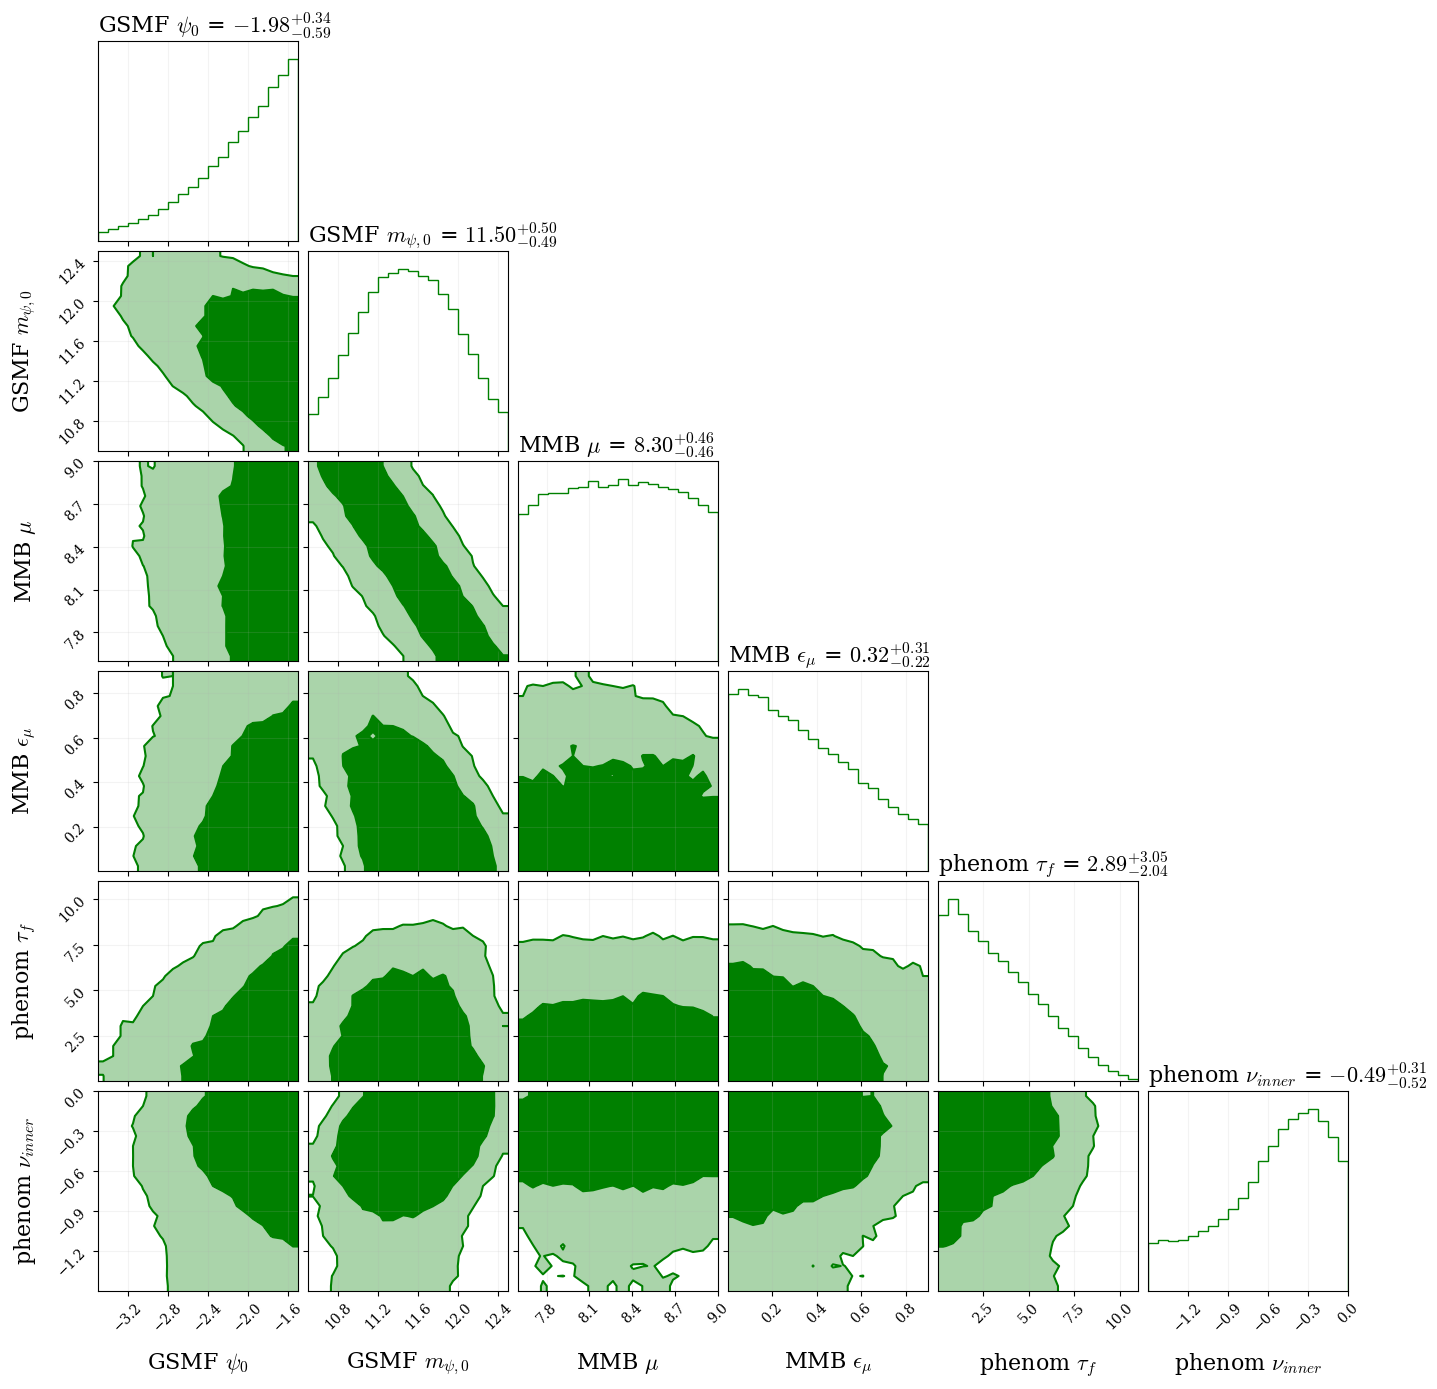

In [4]:
# mcmc using GP
chain_path = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/Phenom_Uniform_n2000_r2000_f5/gp_mcmc_log_likelihood_all_freqs/ceffyl_output_hd_mp_dp_curn/chain_1.txt'
data = np.loadtxt(chain_path)

import corner
import numpy as np
import matplotlib.pyplot as plt
# index 0 - psi0
# index 1 - gsmf_mchar0_log10
# index 2 - mmb_mamp_log10
# index 3 - mmb_scatter_dex
# index 4 - hard_time
# index 5 - hard_gamma_inner

# corner with selected params
data_copy = data
data_copy = data_copy[:, [0, 1, 2, 3, 4, 5]]

print(f'updated chain length: {data_copy.shape}')
# print(f'path to updated mcmc chain: {updated_chain_path}')

labels = [r"GSMF $\psi_0$", r"GSMF $m_{\psi, 0}$", r"MMB $\mu$", r"MMB $\epsilon_{\mu}$", r"phenom $\tau_f$", r"phenom $\nu_{inner}$"]


# ranges for astro params as seen in fig 10 of agazie2023
ranges = [(-3.5, -1.5), (10.5, 12.5), (7.6, 9), (0, 0.9), (0, 11), (-1.5, 0)] # changed the lower limit on vt chain from 0 to 100 to avoid the edge effect (29.10.2025)

# Generate the corner plot with partial limits
fig = corner.corner(
    data_copy,
    labels=labels,
    show_titles=True,
    plot_density=True,
    plot_contours=True,
    fill_contours=True,  # This makes the contour regions filled with color
    # levels=[0.68, 0.95, 0.997],  # Confidence levels
    levels=[0.68, 0.95],  # Confidence levels
    plot_datapoints=False,      # ← turn off the scatter
    color='green',
    label_kwargs={"fontsize": 16},
    title_kwargs={"fontsize": 16, "loc": "left"},
    # fig=plt.figure(figsize=(6, 6)),
    range=ranges  # Apply limits only to the first two
)


plt.show()


## MCMC using NNs (figure 7)

updated chain length: (512000, 6)


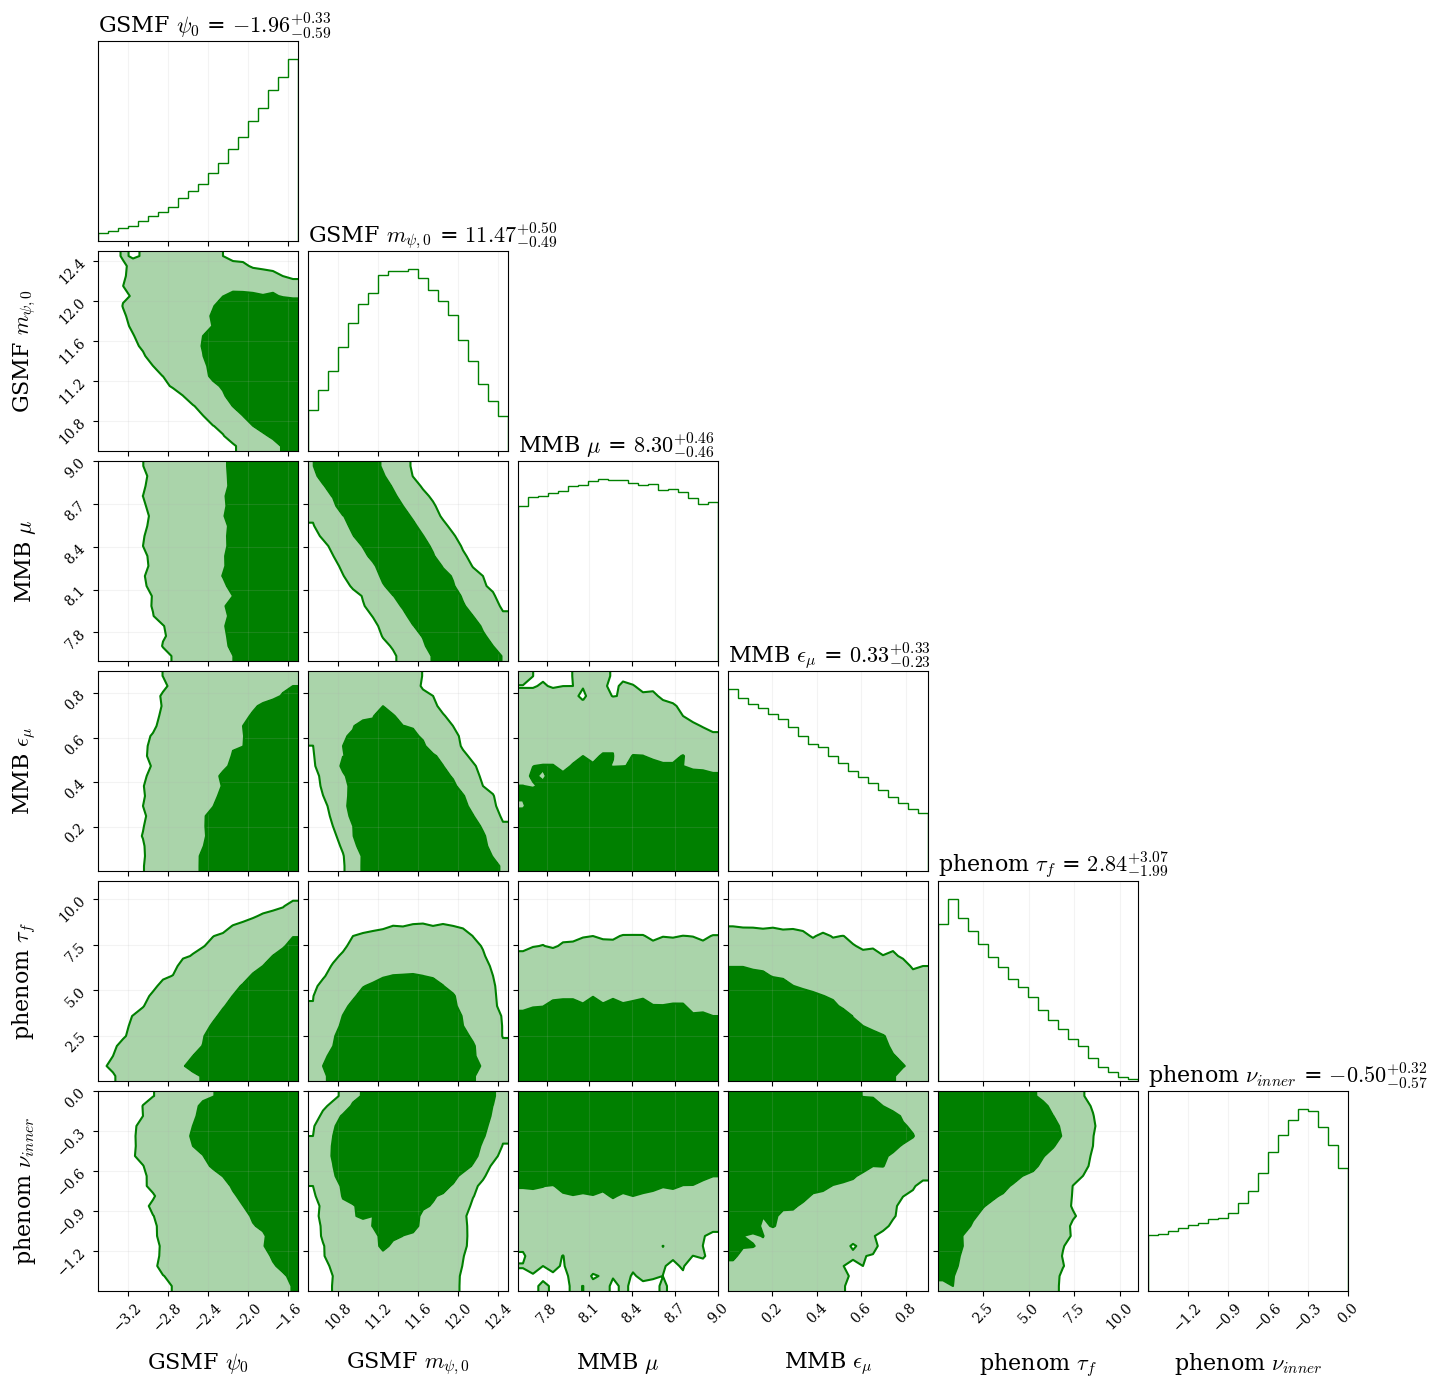

In [5]:
# mcmc using GP
chain_path = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/Phenom_Uniform_n2000_r2000_f5/nn_mcmc_log_likelihood_all_freqs/ceffyl_output_hd_mp_dp_curn/chain_1.txt'
data = np.loadtxt(chain_path)

import corner
import numpy as np
import matplotlib.pyplot as plt
# index 0 - psi0
# index 1 - gsmf_mchar0_log10
# index 2 - mmb_mamp_log10
# index 3 - mmb_scatter_dex
# index 4 - hard_time
# index 5 - hard_gamma_inner

# corner with selected params
data_copy = data
data_copy = data_copy[:, [0, 1, 2, 3, 4, 5]]

print(f'updated chain length: {data_copy.shape}')
# print(f'path to updated mcmc chain: {updated_chain_path}')

labels = [r"GSMF $\psi_0$", r"GSMF $m_{\psi, 0}$", r"MMB $\mu$", r"MMB $\epsilon_{\mu}$", r"phenom $\tau_f$", r"phenom $\nu_{inner}$"]


# ranges for astro params as seen in fig 10 of agazie2023
ranges = [(-3.5, -1.5), (10.5, 12.5), (7.6, 9), (0, 0.9), (0, 11), (-1.5, 0)] # changed the lower limit on vt chain from 0 to 100 to avoid the edge effect (29.10.2025)

# Generate the corner plot with partial limits
fig = corner.corner(
    data_copy,
    labels=labels,
    show_titles=True,
    plot_density=True,
    plot_contours=True,
    fill_contours=True,  # This makes the contour regions filled with color
    # levels=[0.68, 0.95, 0.997],  # Confidence levels
    levels=[0.68, 0.95],  # Confidence levels
    plot_datapoints=False,      # ← turn off the scatter
    color='green',
    label_kwargs={"fontsize": 16},
    title_kwargs={"fontsize": 16, "loc": "left"},
    # fig=plt.figure(figsize=(6, 6)),
    range=ranges  # Apply limits only to the first two
)

plt.show()
